# PSD for OU process


This notebook compares the PSD defined by an OU process in the timing residuals with that commonly seen in pulsar timing 

The "traditional" PSD typically used by pulsar people is:


$$ P(f) = \frac{A^2}{12 \pi^2} \left( \frac{f}{f_{\text{yr}}}\right)^{-\alpha} [\text{Units: } \text{yr}^{3}]$$ 



See e.g. https://github.com/vallis/libstempo/blob/master/libstempo/toasim.py#L298 or Equation 7.13 (mind the units!) from https://arxiv.org/pdf/2105.13270 or Equation 1 in https://arxiv.org/pdf/2306.16229


---

# Derivation of PSD for Time Fluctuations from Ornstein-Uhlenbeck Process

## Starting with the Ornstein-Uhlenbeck SDE
We begin with the Ornstein-Uhlenbeck stochastic differential equation:

$$\frac{dx}{dt} = -\gamma x + \chi(t;\sigma)$$

where $\chi(t;\sigma)$ is white noise with standard deviation $\sigma$.

## PSD of the Ornstein-Uhlenbeck process
Converting to the frequency domain using the Fourier transform:

$$i\omega\tilde{x}(\omega) = -\gamma\tilde{x}(\omega) + \tilde{\chi}(\omega)$$

Solving for $\tilde{x}(\omega)$:

$$\tilde{x}(\omega) = \frac{\tilde{\chi}(\omega)}{i\omega + \gamma}$$

The PSD of $x$ is then:

$$S_x(\omega) = |\tilde{x}(\omega)|^2 = \frac{|\tilde{\chi}(\omega)|^2}{|i\omega + \gamma|^2} = \frac{\sigma^2}{\omega^2 + \gamma^2}$$

Converting to frequency $f$ where $\omega = 2\pi f$:

$$S_x(f) = \frac{\sigma^2}{(2\pi f)^2 + \gamma^2}$$

This can be rewritten as:

$$S_x(f) = \frac{\sigma^2/\gamma^2}{1 + (f/f_c)^2}$$

where $f_c = \gamma/(2\pi)$ is the corner frequency.

## PSD of phase fluctuations $\phi$
Given that $\frac{d\phi}{dt} = x$, in the frequency domain:

$$\tilde{x}(f) = i2\pi f \cdot \tilde{\phi}(f)$$

For power spectral densities, this means:

$$S_x(f) = (2\pi f)^2 \cdot S_{\phi}(f)$$

Rearranging and substituting the expression for $S_x(f)$:

$$S_{\phi}(f) = \frac{S_x(f)}{(2\pi f)^2} = \frac{\sigma^2/\gamma^2}{(2\pi f)^2 \cdot [1 + (f/f_c)^2]}$$

Simplifying:

$$S_{\phi}(f) = \frac{\sigma^2}{\gamma^2} \cdot \frac{1}{(2\pi f)^2 [1 + (f/f_c)^2]}$$

## PSD of time fluctuations $\delta t$
Given $\delta t = \phi/f_0$ where $f_0$ is a constant:

$$S_{\delta t}(f) = \left(\frac{1}{f_0}\right)^2 \cdot S_{\phi}(f)$$

Substituting the expression for $S_{\phi}(f)$:

$$S_{\delta t}(f) = \frac{\sigma^2}{(f_0\gamma)^2(2\pi)^2} \cdot \frac{1}{f^2 [1 + (f/f_c)^2]}$$

With $f_c = \gamma/(2\pi)$ remaining the corner frequency.

This PSD has:
- A $1/f^2$ behavior at low frequencies ($f \ll f_c$)
- A $1/f^4$ behavior at high frequencies ($f \gg f_c$)
- Units of s²/Hz

In [7]:
import numpy as np



# Constants and unit conversions
seconds_per_year = 365.25 * 24 * 60 * 60  # seconds in a year

def traditional_psd(f, A, alpha):
    """Traditional PSD model: P(f) = A^2/(12*pi^2) * (f/f_ref)^(-alpha) [yr^3]"""

    #First calculate in yr^{3}
    f_ref = 1/seconds_per_year
    psd_yr = (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) 


    # Converting from yr^3 to s^3 for consistency
  
    return psd_yr * seconds_per_year**3

def ou_based_psd_TN(f, sigma, gamma, f0):
    """PSD derived from OU process: S_delta_t(f) = sigma^2/((f0*gamma)^2*(2*pi)^2) * 1/(f^2[1 + (f/fc)^2])"""
    fc = gamma / (2 * np.pi)
    return (sigma**2 / ((f0 * gamma)**2 * (2 * np.pi)**2)) * (1 / (f**2 * (1 + (f/fc)**2))) #this is in s^2/Hz

In [8]:
f_range = np.logspace(-9,-6,10)
A = 1e-14  # Example amplitude. See https://github.com/ipta/mdc2/blob/master/group1/group1_psr_noise.json
alpha = 3
psd_trad = traditional_psd(f_range,A,alpha)
psd_ou = ou_based_psd_TN(f=f_range,sigma=2e-15,gamma=1e-9,f0=1e3)

Text(0, 0.5, 'P(f) [s^3]')

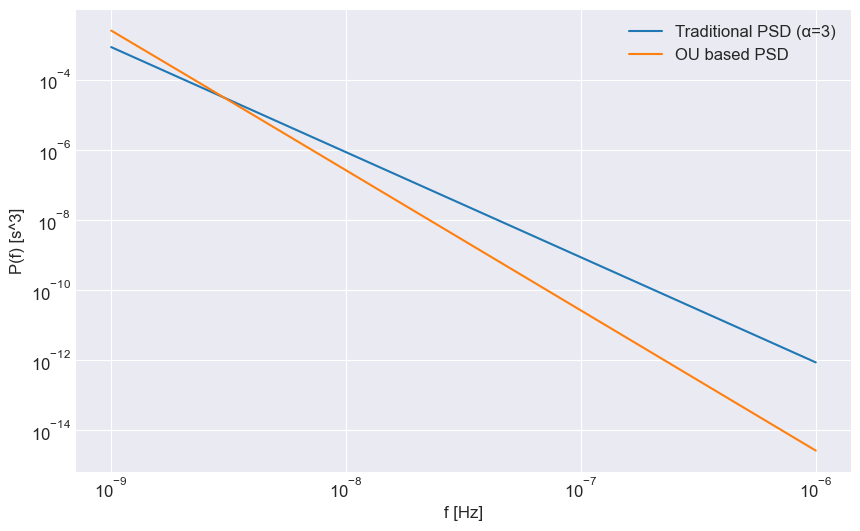

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')

# Gravitational waves.

The GW PSD has the same form, just with different amplitude and exponent. Lets see how that looks:

In [10]:
import numpy as np 
def ou_based_psd_GW(f, sigma, gamma):
    """PSD derived from OU process: S_delta_t(f) = sigma^2/((f0*gamma)^2*(2*pi)^2) * 1/(f^2[1 + (f/fc)^2])"""
    fc = gamma / (2 * np.pi)
    return (sigma**2 / ((gamma)**2 * (2 * np.pi)**2)) * (1 / (f**2 * (1 + (f/fc)**2))) #this is in s^2/Hz

In [38]:
f_range = np.logspace(-9,-6,10)
A = 1e-14  # Example amplitude. See https://github.com/ipta/mdc2/blob/master/group1/group1_gw_parameters.json
alpha = 13/3
psd_trad = traditional_psd(f_range,A,alpha)

gamma = 1e-9
h2 = 1e-25
print(np.sqrt(h2))
sigma2 = h2*gamma/6#ignoring HD
sigma = np.sqrt(sigma2)
psd_ou = ou_based_psd_GW(f=f_range,sigma=sigma,gamma=gamma)

3.162277660168379e-13


Text(0, 0.5, 'P(f) [s^3]')

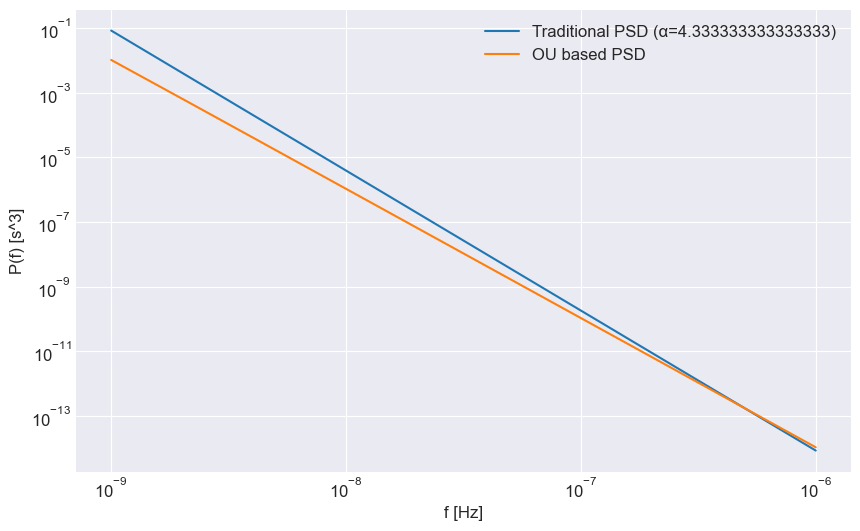

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')